# Math 432: Kernel Methods

## Learning Goals
We want to:
- Train a simple **kernel ridge classifier** with $\alpha=(K+\lambda I)^{-1}\mathbf{y}$ and visualize the decision boundary.
- Compare how the polynomial degree affects the boundary shape/smoothness.


In [66]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.style.use('seaborn-v0_8')
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(432)


## Review of kernel methods

We send our original feature vectors $\mathbf{x}_1,\dots,\mathbf{x}_n \in \mathbb{R}^p$ to $\phi(\mathbf{x}_1),\dots,\phi(\mathbf{x}_n) \in \mathbb{R}^d$, higher-dimensional feature space, by a nonlinear function $\phi$.
But we cannot expect to compute with $\phi$ directly. Nor can we expect to compute this matrix:
$$ \Phi = \begin {bmatrix}
 \text{---} & \phi(\mathbf{x}_1) & \text{---} \\
  & \vdots & \\
\text{---} & \phi(\mathbf{x}_n) & \text{---}
\end {bmatrix} $$
But we will compute the *Gram matrix* $K \in \mathbb{R}^{n \times n}$ defined by $K = \Phi \Phi^{-1}$. 

The **kernel trick** allows us to use $\phi$ without computing $\phi$ directly. We use the *kernel function*
$$ k(\mathbf{x},\mathbf{y}) = \phi(\mathbf{x})^{\top} \phi(\mathbf{y}) . $$

For example, *kernel ridge regression* can be done using $K$ and $k$ alone:
$$ \alpha = (K + \lambda I)^{-1} \mathbf{y}$$
$$ \hat{f}(\mathbf{x}) = \sum_{i=1}^n \alpha_i k(\mathbf{x}_i, \mathbf{x})$$

### Examples of kernels
- Homogeneous polynomial: $k(\mathbf{x},\mathbf{y}) = (\mathbf{x}^{\top} \mathbf{y})^d$
- Inhomogeneous polynomial: $k(\mathbf{x},\mathbf{y}) = (1 + \mathbf{x}^{\top} \mathbf{y})^d$
- Gaussian kernel: $k(\mathbf{x},\mathbf{y}) = \exp(- \|\mathbf{x}-\mathbf{y}\|^2/ \sigma^2)$


## Synthetic 2D data
We generate points near an ellipse defined by semi-axes $a,b$ and rotation angle $\theta$.
Label $y=0$ for points **inside** the ellipse and $y=1$ for points **outside**. Plus a little noise.

In [67]:
def poly_hom_kernel(X, Y=None, d=3):
    Y = X if Y is None else Y
    return (X @ Y.T) ** d

def poly_inh_kernel(X, Y=None, d=3):
    Y = X if Y is None else Y
    return (1.0 + X @ Y.T) ** d

def rbf_kernel(X, Y=None, gamma=1.0):
    Y = X if Y is None else Y
    Xn = np.sum(X**2, axis=1)[:, None]
    Yn = np.sum(Y**2, axis=1)[None, :]
    sq = Xn + Yn - 2*(X @ Y.T)
    return np.exp(-gamma * sq)


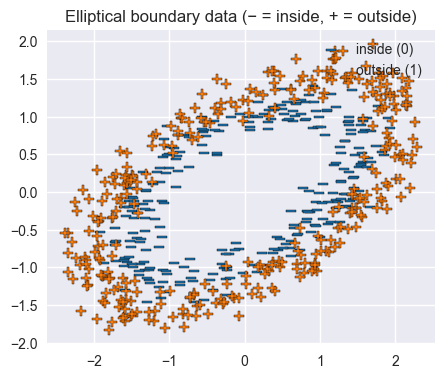

In [68]:
def make_elliptic_data(n=600, a=2.0, b=1.0, angle=np.pi/6, noise=0.12, seed=0):
    """
    Generate points around a rotated ellipse. Boundary is r=1 in ellipse coordinates.
    Inside (r <= 1) -> class 0, Outside (r > 1) -> class 1, plus small noise.
    """
    rng = np.random.default_rng(seed)
    r = rng.uniform(0.7, 1.3, size=n)
    t = rng.uniform(0, 2*np.pi, size=n)
    S = np.diag([a, b])
    R = np.array([[np.cos(angle), -np.sin(angle)],
                  [np.sin(angle),  np.cos(angle)]])
    pts = R @ (S @ np.vstack([r*np.cos(t), r*np.sin(t)]))
    X = pts.T + noise * rng.normal(size=(n,2))
    y = (r > 1.0).astype(float)
    return X, y

X, y = make_elliptic_data()

fig, ax = plt.subplots(figsize=(5,5))
inside = y <= 0.5
outside = y > 0.5
ax.scatter(X[inside,0], X[inside,1], marker='$-$', s=60, color='tab:blue', edgecolors='k', label='inside (0)')
ax.scatter(X[outside,0], X[outside,1], marker='$+$', s=60, color='tab:orange', edgecolors='k', label='outside (1)')
ax.set_title('Elliptical boundary data (− = inside, + = outside)')
ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.show()


## Exercise 1: Kernel ridge classification
We solve $(K+\lambda I)\alpha = \mathbf{y}$, then predict on new points via 
$$\hat f(\mathbf{x}) = \sum_{i=1}^n \alpha_i k(\mathbf{x}_i, \mathbf{x}).$$
Classify by $\hat{\mathbf{y}} = 1_{\{\hat f(\mathbf{x}) > 0.5\}}$.

In [71]:
def krr_train(K, y, lam=1e-2):
    n = K.shape[0]
    ### Todo: solve K + lambda*I_n = y
    ### use np.linalg.solve
    # return ...

def krr_predict(alpha, X_train, X_test, kernel, **kparams):
    K_star = kernel(X_test, X_train, **kparams)
    return K_star @ alpha

def accuracy(yhat, ytrue):
    return np.mean((yhat > 0.5) == (ytrue > 0.5))

# train/validation split
idx = np.arange(len(X))
rng = np.random.default_rng(0)
rng.shuffle(idx)
train_idx = idx[:400]
val_idx   = idx[400:]
Xtr, ytr = X[train_idx], y[train_idx]
Xva, yva = X[val_idx],   y[val_idx]


In [72]:
def plot_boundary(ax, X_train, y_train, kernel, kparams, lam=1e-2, levels=[0.5],
                  title='', cmap='cividis'):
    K = kernel(X_train, **kparams)
    alpha = krr_train(K, y_train, lam=lam)

    x1min, x1max = X_train[:,0].min()-0.5, X_train[:,0].max()+0.5
    x2min, x2max = X_train[:,1].min()-0.5, X_train[:,1].max()+0.5
    gx = np.linspace(x1min, x1max, 200)
    gy = np.linspace(x2min, x2max, 200)
    GX, GY = np.meshgrid(gx, gy)
    Xg = np.c_[GX.ravel(), GY.ravel()]

    Z = krr_predict(alpha, X_train, Xg, kernel, **kparams).reshape(GX.shape)

    ax.contourf(GX, GY, Z, levels=np.linspace(0,1,11), cmap=cmap, alpha=0.35)
    ax.contour(GX, GY, Z, levels=levels, colors='k', linewidths=1.5)

    inside = y_train <= 0.5
    outside = y_train > 0.5
    ax.scatter(X_train[inside,0], X_train[inside,1], marker='$-$', s=60, color='tab:blue', edgecolors='k', label='inside (0)')
    ax.scatter(X_train[outside,0], X_train[outside,1], marker='$+$', s=60, color='tab:orange', edgecolors='k', label='outside (1)')
    ax.set_aspect('equal')
    ax.set_title(title)
    # Legend
    handles = [
        Line2D([0],[0], marker='$-$', color='w', markerfacecolor='tab:blue', markeredgecolor='k', markersize=10, linestyle='None', label='inside (0)'),
        Line2D([0],[0], marker='$+$', color='w', markerfacecolor='tab:orange', markeredgecolor='k', markersize=10, linestyle='None', label='outside (1)')
    ]
    ax.legend(handles=handles, loc='upper right')
    return Z


## Kernel Ridge Classification
We grid-search $\lambda$, $d$ (for polynomials), and $\gamma$ (for RBF). We report validation accuracy and highlight the best settings.


In [55]:
### This is for testing; you can ignore it
def cond_stats(K, lam):
    K_reg = (K + lam*np.eye(K.shape[0]))
    K_reg = (K_reg + K_reg.T)/2.0
    evals = np.linalg.eigvalsh(K_reg)
    kappa = evals.max()/max(evals.min(), 1e-15)
    print(f"λ={lam} | min eig≈{evals.min():.3e} | cond≈{kappa:.3e}")

# Example checks:
cond_stats(poly_inh_kernel(Xtr, d=5), lam=1e-2)
cond_stats(rbf_kernel(Xtr, gamma=3.0), lam=1e-2)


λ=0.01 | min eig≈1.000e-02 | cond≈4.618e+07
λ=0.01 | min eig≈1.000e-02 | cond≈3.800e+03


/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:16: RuntimeWarning: divide by zero encountered in matmul
  D = X @ Y.T
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:16: RuntimeWarning: overflow encountered in matmul
  D = X @ Y.T
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:16: RuntimeWarning: invalid value encountered in matmul
  D = X @ Y.T


In [56]:
def grid_search():
    results = []
    for lam in [1e-2, 1e-1, 1.0, 2.0]:
        for d in [1,2,3,4]:
            Ktr = poly_hom_kernel(Xtr, d=d)
            alpha = krr_train(Ktr, ytr, lam)
            acc = accuracy(krr_predict(alpha, Xtr, Xva, poly_hom_kernel, d=d), yva)
            results.append(('poly_hom', {'d':d}, lam, acc))
            Ktr = poly_inh_kernel(Xtr, d=d)
            alpha = krr_train(Ktr, ytr, lam)
            acc = accuracy(krr_predict(alpha, Xtr, Xva, poly_inh_kernel, d=d), yva)
            results.append(('poly_inh', {'d':d}, lam, acc))
        for gamma in [0.2, 1.0, 3.0]:
            Ktr = rbf_kernel(Xtr, gamma=gamma)
            alpha = krr_train(Ktr, ytr, lam)
            acc = accuracy(krr_predict(alpha, Xtr, Xva, rbf_kernel, gamma=gamma), yva)
            results.append(('rbf', {'gamma':gamma}, lam, acc))
    return sorted(results, key=lambda t: t[3], reverse=True)

results = grid_search()
print('Top 10 validation results:')
for r in results[:10]:
    name, params, lam, acc = r
    print('{} | params={} | lam={} | val_acc={:.3f}'.format(name, params, lam, acc))
best = results[0]
best


Top 10 validation results:
poly_hom | params={'d': 2} | lam=2.0 | val_acc=0.860
poly_inh | params={'d': 4} | lam=0.01 | val_acc=0.855
poly_hom | params={'d': 2} | lam=0.1 | val_acc=0.855
poly_hom | params={'d': 2} | lam=1.0 | val_acc=0.855
poly_hom | params={'d': 2} | lam=0.01 | val_acc=0.850
rbf | params={'gamma': 0.2} | lam=0.01 | val_acc=0.845
poly_inh | params={'d': 4} | lam=0.1 | val_acc=0.845
poly_inh | params={'d': 4} | lam=1.0 | val_acc=0.845
rbf | params={'gamma': 1.0} | lam=1.0 | val_acc=0.845
rbf | params={'gamma': 1.0} | lam=2.0 | val_acc=0.845


/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:8: RuntimeWarning: divide by zero encountered in matmul
  D = X @ Y.T
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:8: RuntimeWarning: overflow encountered in matmul
  D = X @ Y.T
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:8: RuntimeWarning: invalid value encountered in matmul
  D = X @ Y.T
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:48: RuntimeWarning: divide by zero encountered in matmul
  return K_star @ np.asarray(alpha, dtype=np.float64)
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:48: RuntimeWarning: overflow encountered in matmul
  return K_star @ np.asarray(alpha, dtype=np.float64)
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:48: RuntimeWarning: invalid value encountered in matmul
  return K_star @ np.asarray(alpha, dtype=np.float64)
/va

('poly_hom', {'d': 2}, 2.0, np.float64(0.86))

## Decision Boundaries
We visualize the top three settings from the grid search.


/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:8: RuntimeWarning: divide by zero encountered in matmul
  D = X @ Y.T
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:8: RuntimeWarning: overflow encountered in matmul
  D = X @ Y.T
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:8: RuntimeWarning: invalid value encountered in matmul
  D = X @ Y.T
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:48: RuntimeWarning: divide by zero encountered in matmul
  return K_star @ np.asarray(alpha, dtype=np.float64)
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:48: RuntimeWarning: overflow encountered in matmul
  return K_star @ np.asarray(alpha, dtype=np.float64)
/var/folders/kf/br28c8hn59sbzh5kdm2wclw80000gn/T/ipykernel_15899/964189411.py:48: RuntimeWarning: invalid value encountered in matmul
  return K_star @ np.asarray(alpha, dtype=np.float64)
/va

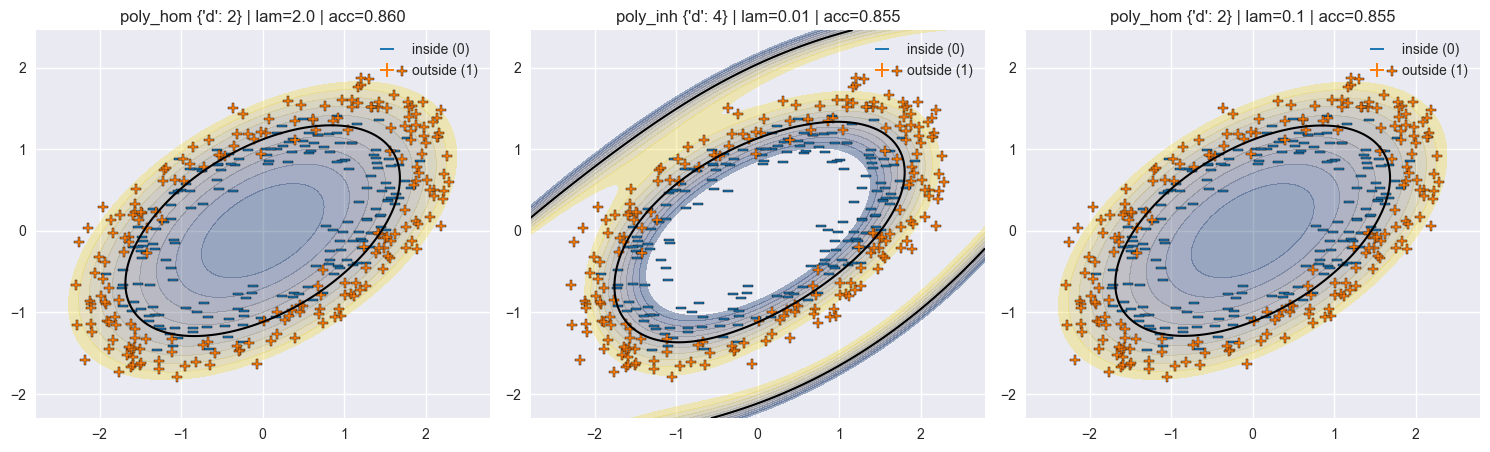

In [57]:
fig, axs = plt.subplots(1,3, figsize=(15,4.5))
for ax, (name, params, lam, acc) in zip(axs, results[:3]):
    title = '{} {} | lam={} | acc={:.3f}'.format(name, params, lam, acc)
    if name=='rbf':
        plot_boundary(ax, Xtr, ytr, rbf_kernel, params, lam=lam, title=title)
    elif name=='poly_hom':
        plot_boundary(ax, Xtr, ytr, poly_hom_kernel, params, lam=lam, title=title)
    else:
        plot_boundary(ax, Xtr, ytr, poly_inh_kernel, params, lam=lam, title=title)
plt.tight_layout(); plt.show()
